### `etd_tests.ipynb` 
*Created: Sept 22, 2026* <br/>
Notebook for testing some Exponential Time Differencing (ETD) solvers by comparing them against trusted reference solvers from `OrdinaryDiffEq.jl`. We also test against exact solutions, when available.

In [1]:
using OrdinaryDiffEq, CairoMakie, NBInclude, UnPack, Printf, Test, LinearAlgebra, LaTeXStrings, Statistics
using OrdinaryDiffEqExponentialRK, SciMLOperators 
import OrdinaryDiffEqCore: OrdinaryDiffEqAlgorithm  

In [6]:
#Import the ETD solvers 
@nbinclude("../etd_euler.ipynb")
@nbinclude("../etd_rk2.ipynb")
@nbinclude("../etd_rk3.ipynb")
@nbinclude("../etd_rk4.ipynb")

#Import ODE test problems
@nbinclude("test_problems.ipynb")

#Use desired plotting defaults for Makie 
@nbinclude("../../../../../../../set_makie_defaults.ipynb")

In [7]:
struct SemilinearTestProblem{M, F, U, P, S}
    A::M
    f::F
    u0::U
    tspan::Tuple{Float64, Float64}
    p::P
    exact_solution::S
end 

function SemilinearTestProblem(A::M, f::F, u0::U, tspan::NTuple{2,<:Real}, p::P = nothing; exact_solution::S = nothing) where {M,F,U,P,S}
    tspan = Float64.(tspan)
    return SemilinearTestProblem(A, f, u0, tspan, p, exact_solution)
end

SemilinearTestProblem

In [10]:
function etd_euler(prob::SemilinearTestProblem; Δt::Float64)
    return etd_euler(prob.A, prob.f, prob.u0, prob.tspan, prob.p; Δt = Δt)
end 

etd_euler (generic function with 3 methods)

#### **Test 1: A Scalar Riccati Equation**

##### **ODE: $\displaystyle u' = -au + u^2, \quad u(0) = u_0, \quad 0 < u_0 < a$**

##### **Exact Solution:**  $\quad \displaystyle u(t) = \frac{a}{1 - \left(1 - \frac{a}{u_0} \right)e^{at}}$

- We have $A = -a$ and $f(u,t) = u^2$
- Note that $\lim\limits_{t \to \infty} u(t) = 0$, provided $a > 0$. 

In [12]:
#Test ETD Euler using a *scalar* equation
a = 3.0
A = -a 
u0 = 1.0 
p = (a = a, u0 = u0)
riccati_nonlin(u,p,t) = u^2 

function riccati_exact(t,p)
    @unpack a, u0 = p
    return a ./ (1.0 - (1.0 - a/u0)*exp(a*t))
end 

riccati = SemilinearTestProblem(A, riccati_nonlin, u0, (0.0, 2.0), p; exact_solution = riccati_exact);

#Now solve the riccati equation using `etd_euler`
sol = etd_euler(riccati; Δt = 0.01)

u_approx = sol.u
u_exact = riccati_exact.(sol.t, Ref(sol.p));

l_inf_norm = maximum(u_approx .- u_exact)
@printf("l_inf_error = %.4e", l_inf_norm)

# fig = Figure(size = (400,400))
# ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"u", title = "ETD Euler")
# scatter!(sol.t, u_approx, label = "numerical", color = :orange, markersize = 6)
# lines!(sol.t, u_exact, label = "exact", color = :blue)
# axislegend(position = :rt, ax)
# display(fig)

l_inf_error = 2.8202e-03

#### **Test 2: Nonlinear System** 
$$A = \begin{pmatrix} -100 & \phantom{-}0 \\ 0 & -1 \end{pmatrix}, \quad F(\mathbf{u},p,t) = \begin{pmatrix} \cos t + 100 \sin t + u_1^2 - \sin^2 t \\ - \sin t + \cos t + u_1 u_2 - \sin t \cos t \end{pmatrix}, \quad \mathbf{u}(0) = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

##### **Exact solution:** $$\mathbf{u}(t) = \begin{pmatrix} u_1(t) \\ u_2(t) \end{pmatrix} = \begin{pmatrix} \sin t \\ \cos t \end{pmatrix}$$



In [15]:
function rotation_nonlin(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

rotation_exact(t, p) = [sin(t), cos(t)]

A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]
p = nothing

#Now solve the rotation equation using `etd_euler`
rotation = SemilinearTestProblem(A, rotation_nonlin, u0, (0.0, 2.0), p; exact_solution = rotation_exact);
sol = etd_euler(rotation; Δt = 0.01);

u_approx = sol.u
u_exact = rotation_exact.(sol.t, Ref(sol.p));

l_inf_norm = maximum(map(err -> norm(err), u_approx .- u_exact))
@printf("l_inf_error = %.4e", l_inf_norm)

l_inf_error = 7.0043e-03

#### **Test 3: The Van der Pol Oscillator** 

\begin{align*}
   \ddot{x} + \mu(x^2 - 1)\dot{x} + x = 0. 
\end{align*}

Letting $y = \dot{x}$, we can rewrite this second-order ODE as a first order system: 
\begin{align*}
   \dot{x} &= y \\[5pt]
   \dot{y} &= -\mu(x^2 - 1)y - x 
\end{align*}

or equivalently, 

\begin{align*}
   \begin{pmatrix} 
      \dot{x} \\ \dot{y}
   \end{pmatrix}
   = 
   \begin{pmatrix}
      0 & 1 \\
      -1 & \mu
   \end{pmatrix}
   \begin{pmatrix} 
      x \\ y 
    \end{pmatrix}
    + 
    \begin{pmatrix} 
      0 \\ -\mu x^2 
    \end{pmatrix}
\end{align*}

This is a good stiff ODE system for solver testing.

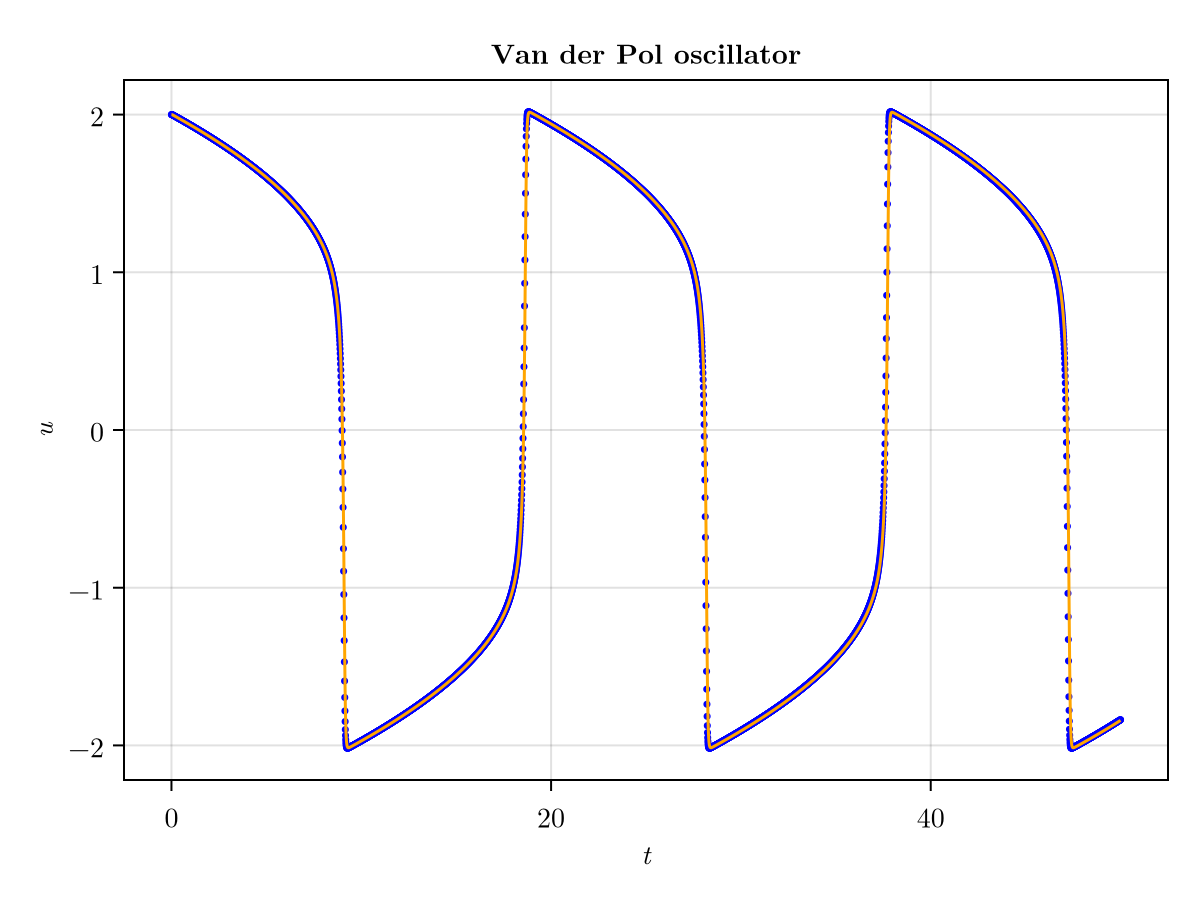

CairoMakie.Screen{IMAGE}


In [54]:
#Van der Pol oscillator
function vdp_nonlin(u,p,t)
    #p is usually denoted by μ 
    return [0.0, -p*(u[1])^2 * u[2]]
end 

p = 10.0
A_vdp = [0.0 1.0; -1.0 p] 
u0 = [2.0, 0.0]

vanderpol = SemilinearTestProblem(A_vdp, vdp_nonlin, u0, (0.0, 50.0), p);
sol = etd_euler(vanderpol; Δt = 0.01);

#Now compare with reference solution
function vanderpol_rhs(u,p,t)
    x, y = u
    dx = y
    dy = -p*(x^2 - 1)*y - x 
    return [dx, dy]
end

vdp_prob = ODEProblem(vanderpol_rhs, u0, (0.0, 50.0), p)

sol_reference = solve(vdp_prob, alg = Rosenbrock23(), saveat = sol.t);

fig = Figure()
ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"u", title = "Van der Pol oscillator")
scatter!(sol.t, getindex.(sol.u, 1), color = :blue, markersize = 5, label = "ETD-Euler")
lines!(sol.t, getindex.(sol_reference.u, 1), color = :orange, label = "Reference sol")
display(fig)

In [ ]:
# Problem              Type    Tags                  Metric          Value        Tol        Status
# -----------------------------------------------------------------------------------------------
# Exponential decay    scalar  exact, nonstiff        final error     2.1e-8      1.0e-6     PASS
# Logistic             scalar  exact, nonlinear       final error     4.8e-7      1.0e-6     PASS
# Riccati              scalar  blow-up, nonlinear     final error     8.2e-6      1.0e-6     FAIL
# Lotka-Volterra       system  invariant, nonlinear   invariant drift 3.4e-5      1.0e-4     PASS
# SIR                  system  positivity             min component   1.2e-10     0          PASS
# Robertson            system  stiff                  final error     6.7e-5      1.0e-4     PASS
# Van der Pol          system  stiff-ish              steps           982         --         WARN